# Feature Extraction - Figshare Dataset

**Objective:** Extract multi-domain features from windowed sensor data for FoG detection.

**Features extracted:**
- Time-domain: mean, std, skewness, kurtosis, RMS, median, IQR, cadence
- Frequency-domain: PSD peak, total energy, band powers, freezing index
- Wavelet: energy per level, entropy
- Nonlinear: sample entropy, fractal dimension

**Pipeline:**
1. Load windowed LOSO splits
2. Initialize signal cleaner and feature extractor
3. Process all folds: clean signals → extract features → save CSVs
4. Analyze extracted features with visualizations

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from tqdm import tqdm


from features import FeatureExtractor
from processing import SignalCleaner

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

## 1. Load Windowed Data

In [3]:
# Load binary LOSO splits
data_path = Path('../../outputs/datasets_csv/figshare_loso_windows_binary.pkl')

with open(data_path, 'rb') as f:
    loso_splits = pickle.load(f)

print(f"✅ Loaded {len(loso_splits)} LOSO folds")
print(f"   Total train windows: {sum([len(fold['y_train']) for fold in loso_splits]):,}")
print(f"   Total test windows: {sum([len(fold['y_test']) for fold in loso_splits]):,}")

✅ Loaded 24 LOSO folds
   Total train windows: 97,763
   Total test windows: 1,410


## 2. Initialize Cleaner and Extractor

In [4]:
# Signal cleaner (MAD-based outlier detection)
cleaner = SignalCleaner(
    outlier_thresh_mul=3.0,
    outlier_poly_order=3
)

print("✅ Signal cleaner initialized")
print(f"   MAD threshold: {cleaner.outlier_thresh_mul}")
print(f"   Polynomial order: {cleaner.outlier_poly_order}")

✅ Signal cleaner initialized
   MAD threshold: 3.0
   Polynomial order: 3


In [ ]:
# Feature extractor
SAMPLING_RATE = 128  # Hz for Figshare

extractor = FeatureExtractor(
    sampling_rate=SAMPLING_RATE,
    extract_time=True,
    extract_frequency=True,
    extract_wavelet=True,
    extract_nonlinear=True  # Enabled for robust cross-dataset pipeline
)

# Channel groups for per-sensor magnitude computation
# Figshare: 6 channels — acc (0-2) + gyr (3-5) on lower back
CHANNEL_GROUPS = {
    'acc_lower_back': [0, 1, 2],
    'gyr_lower_back': [3, 4, 5],
}

print("✅ Feature extractor initialized")
print(f"   Sampling rate: {SAMPLING_RATE} Hz")
print(f"   Time-domain: ✅")
print(f"   Frequency-domain: ✅")
print(f"   Wavelet: ✅")
print(f"   Nonlinear: ✅")
print(f"   Channel groups: {list(CHANNEL_GROUPS.keys())}")

✅ Feature extractor initialized
   Sampling rate: 128 Hz
   Time-domain: ✅
   Frequency-domain: ✅
   Wavelet: ✅
   Nonlinear: ❌ (disabled)
   Channel groups: ['acc_lower_back', 'gyr_lower_back']


## 3. Process All LOSO Folds

Extract features from all folds and save to CSV files.

In [6]:
# Output directory
feature_output_dir = Path('../../outputs/figshare_features')
feature_output_dir.mkdir(parents=True, exist_ok=True)

print("🚀 Processing all LOSO folds...")
print("=" * 70)

for fold in tqdm(loso_splits, desc="Processing folds"):
    test_subject = fold['test_subject']

    # 1. Clean signals (remove outliers)
    X_train_clean = cleaner.clean_windows(fold['X_train'])
    X_test_clean  = cleaner.clean_windows(fold['X_test'])

    # 2. Extract features (parallel processing with all CPU cores)
    X_train_features = extractor.extract_from_windows(
        X_train_clean, n_jobs=-1, verbose=True, channel_groups=CHANNEL_GROUPS)
    X_test_features = extractor.extract_from_windows(
        X_test_clean, n_jobs=-1, verbose=True, channel_groups=CHANNEL_GROUPS)

    # 3. Save to CSV
    fold_dir = feature_output_dir / f'fold_subj_{test_subject}'
    fold_dir.mkdir(parents=True, exist_ok=True)

    X_train_features.to_csv(fold_dir / 'X_train_features.csv', index=False)
    pd.Series(fold['y_train'], name='label').to_csv(fold_dir / 'y_train.csv', index=False)
    pd.Series(fold['subjects_train'], name='subject').to_csv(fold_dir / 'subjects_train.csv', index=False)
    X_test_features.to_csv(fold_dir / 'X_test_features.csv', index=False)
    pd.Series(fold['y_test'], name='label').to_csv(fold_dir / 'y_test.csv', index=False)

print("\n" + "=" * 70)
print(f"✅ Feature extraction complete for {len(loso_splits)} folds")
print(f"📁 Output directory: {feature_output_dir}")
print("=" * 70)

🚀 Processing all LOSO folds...


Processing folds:   0%|          | 0/24 [00:00<?, ?it/s]

🚀 Extracting features in parallel (-1 jobs)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:   12.9s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   13.1s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:   13.1s
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:   13.1s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:   13.2s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.1919458598816862s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed:   13.2s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:   13.2s
[Parallel(n_jobs=-1)]: Done  96 tasks      | elapsed:   13.3s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.0776212215423584s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:   13.3s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.1562025547027588s.) Setting batch_size=8.
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:   13.5s
[Parallel(n_jobs=-

🚀 Extracting features in parallel (-1 jobs)...


...

🚀 Extracting features in parallel (-1 jobs)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Batch computation too fast (0.01931309700012207s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.06634092330932617s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done  74 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.14174604415893555s.) Setting batch_size=8.
[Parallel(n_jobs=-1)]: Done 104 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 164 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 360 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 496 tasks      | elapsed:    0.8s
[Parallel(n_job

🚀 Extracting features in parallel (-1 jobs)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Batch computation too fast (0.021347761154174805s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   3 out of  30 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done   7 out of  30 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  11 out of  30 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  15 out of  30 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  19 out of  30 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  23 out of  30 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  27 out of  30 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed:    0.0s finished
Processing folds: 100%|██████████| 24/24 [04:47<00:00, 11.99s/it]


✅ Feature extraction complete for 24 folds
📁 Output directory: ..\..\outputs\figshare_features


## 4. Load Sample Features for Analysis

Load features from the first fold for visualization and analysis.

In [7]:
# Load first fold for analysis
sample_fold_dir = feature_output_dir / 'fold_subj_S01'

X_train_features = pd.read_csv(sample_fold_dir / 'X_train_features.csv')
y_train = pd.read_csv(sample_fold_dir / 'y_train.csv').squeeze()
X_test_features = pd.read_csv(sample_fold_dir / 'X_test_features.csv')
y_test = pd.read_csv(sample_fold_dir / 'y_test.csv').squeeze()

print(f"📊 Loaded features from: {sample_fold_dir.name}")
print(f"   Train: {X_train_features.shape}")
print(f"   Test: {X_test_features.shape}")
print(f"   Features: {X_train_features.shape[1]}")
print(f"\n📋 First 10 features:")
for i, col in enumerate(X_train_features.columns[:10], 1):
    print(f"   {i}. {col}")

📊 Loaded features from: fold_subj_S01
   Train: (4071, 201)
   Test: (60, 201)
   Features: 201

📋 First 10 features:
   1. ch0_mean
   2. ch0_std
   3. ch0_skew
   4. ch0_kurt
   5. ch0_median
   6. ch0_iqr
   7. ch0_rms
   8. ch0_peak_to_peak
   9. ch0_zero_crossing_rate
   10. ch0_psd_peak_freq


## 5. Feature Statistics

In [8]:
# Statistical summary
print("📈 Feature Statistics (Train Set):")
print(X_train_features.describe())

📈 Feature Statistics (Train Set):
          ch0_mean      ch0_std     ch0_skew     ch0_kurt   ch0_median  \
count  4071.000000  4071.000000  4071.000000  4071.000000  4071.000000   
mean      0.026262     0.144878    -0.018849     1.149853     0.027201   
std       0.110204     0.097405     0.222892     0.526433     0.111114   
min      -0.320919     0.011306    -0.800106    -1.200573    -0.321662   
25%      -0.053367     0.071583    -0.169179     0.810741    -0.053435   
50%       0.024361     0.124404    -0.027098     1.127933     0.026680   
75%       0.107192     0.194150     0.125709     1.467715     0.107054   
max       0.445473     0.782464     0.807370     3.154159     0.450865   

           ch0_iqr      ch0_rms  ch0_peak_to_peak  ch0_zero_crossing_rate  \
count  4071.000000  4071.000000       4071.000000             4071.000000   
mean      0.135066     0.185421          0.872653                0.130132   
std       0.094761     0.094488          0.563029                0.0

## 6. Feature Distributions: Freeze vs No Freeze

Compare key features between Freeze and No Freeze windows.

📊 Class Distribution:
   No Freeze: 3,421 windows (84.0%)
   Freeze: 650 windows (16.0%)


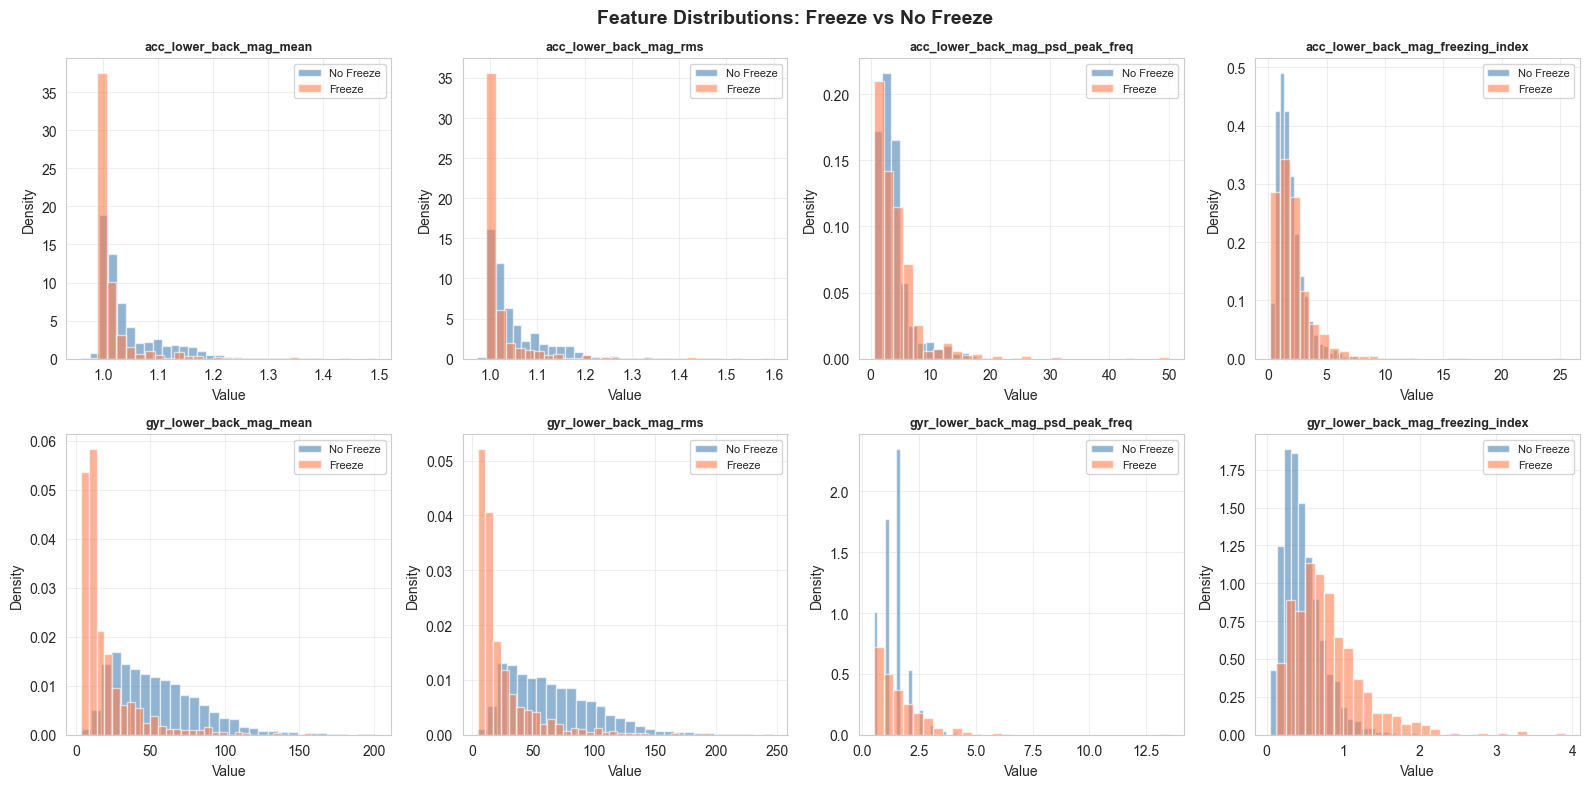

In [9]:
# Separate by class (replace inf so histograms and Cohen's d are not distorted)
features_no_freeze = X_train_features[y_train == 0].replace([np.inf, -np.inf], np.nan)
features_freeze    = X_train_features[y_train == 1].replace([np.inf, -np.inf], np.nan)

print(f"📊 Class Distribution:")
print(f"   No Freeze: {len(features_no_freeze):,} windows ({len(features_no_freeze)/len(X_train_features)*100:.1f}%)")
print(f"   Freeze: {len(features_freeze):,} windows ({len(features_freeze)/len(X_train_features)*100:.1f}%)")

# Select representative features (per-group magnitudes)
feature_subset = [
    'acc_lower_back_mag_mean', 'acc_lower_back_mag_rms',
    'acc_lower_back_mag_psd_peak_freq', 'acc_lower_back_mag_freezing_index',
    'gyr_lower_back_mag_mean', 'gyr_lower_back_mag_rms',
    'gyr_lower_back_mag_psd_peak_freq', 'gyr_lower_back_mag_freezing_index',
]

# Filter to existing features
feature_subset = [f for f in feature_subset if f in X_train_features.columns]

# Visualize distributions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, feat in enumerate(feature_subset[:8]):
    axes[i].hist(features_no_freeze[feat].dropna(), bins=30, alpha=0.6, 
                label='No Freeze', color='steelblue', density=True)
    axes[i].hist(features_freeze[feat].dropna(), bins=30, alpha=0.6, 
                label='Freeze', color='coral', density=True)
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

# Hide unused subplots
for i in range(len(feature_subset), 8):
    axes[i].axis('off')

plt.suptitle('Feature Distributions: Freeze vs No Freeze', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Feature Importance by Variance

Identify features with highest variance (potentially most discriminative).

📊 Top 15 Features by Variance:
 1. gyr_lower_back_mag_wavelet_energy_0 11470214964923.29
 2. ch5_wavelet_energy_0                6330025492130.72
 3. ch4_wavelet_energy_0                375347208600.97
 4. ch3_wavelet_energy_0                112236882773.48
 5. ch5_wavelet_energy_1                66832567482.20
 6. ch5_wavelet_energy_2                24835998343.56
 7. gyr_lower_back_mag_wavelet_energy_1 15519067484.29
 8. ch5_wavelet_energy_3                14356070159.31
 9. gyr_lower_back_mag_wavelet_energy_2 7809342798.92
10. gyr_lower_back_mag_wavelet_energy_3 5266497037.79
11. ch4_wavelet_energy_1                3097720762.81
12. ch5_wavelet_var_0                   1134454046.65
13. ch4_wavelet_energy_2                910411294.56
14. ch3_wavelet_energy_1                651604800.79
15. ch3_wavelet_energy_3                621661886.43


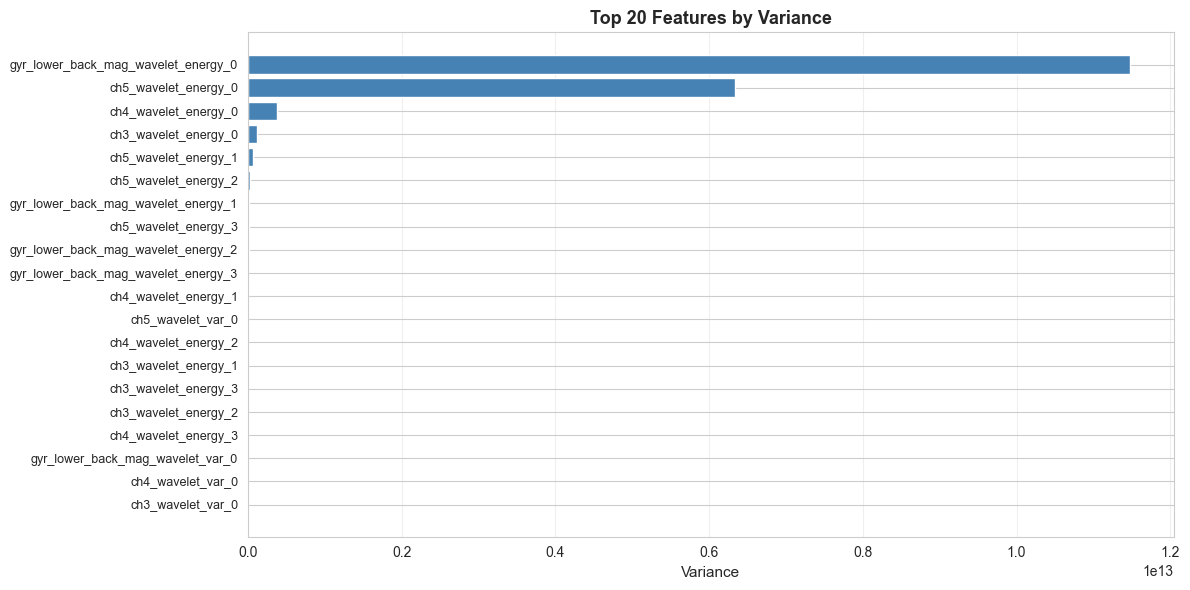

In [10]:
# Calculate variance for each feature (replace inf with NaN before var to avoid inf results)
feature_variance = (
    X_train_features
    .replace([np.inf, -np.inf], np.nan)
    .var()
    .sort_values(ascending=False)
)

print("📊 Top 15 Features by Variance:")
print("=" * 60)
for i, (feat, var) in enumerate(feature_variance.head(15).items(), 1):
    print(f"{i:2d}. {feat:35s} {var:12.2f}")

# Visualize top features by variance
fig, ax = plt.subplots(figsize=(12, 6))
top_features = feature_variance.dropna().head(20)
ax.barh(range(len(top_features)), top_features.values, color='steelblue')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features.index, fontsize=9)
ax.set_xlabel('Variance', fontsize=11)
ax.set_title('Top 20 Features by Variance', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Feature Correlation Analysis

Identify highly correlated features (potential redundancy).

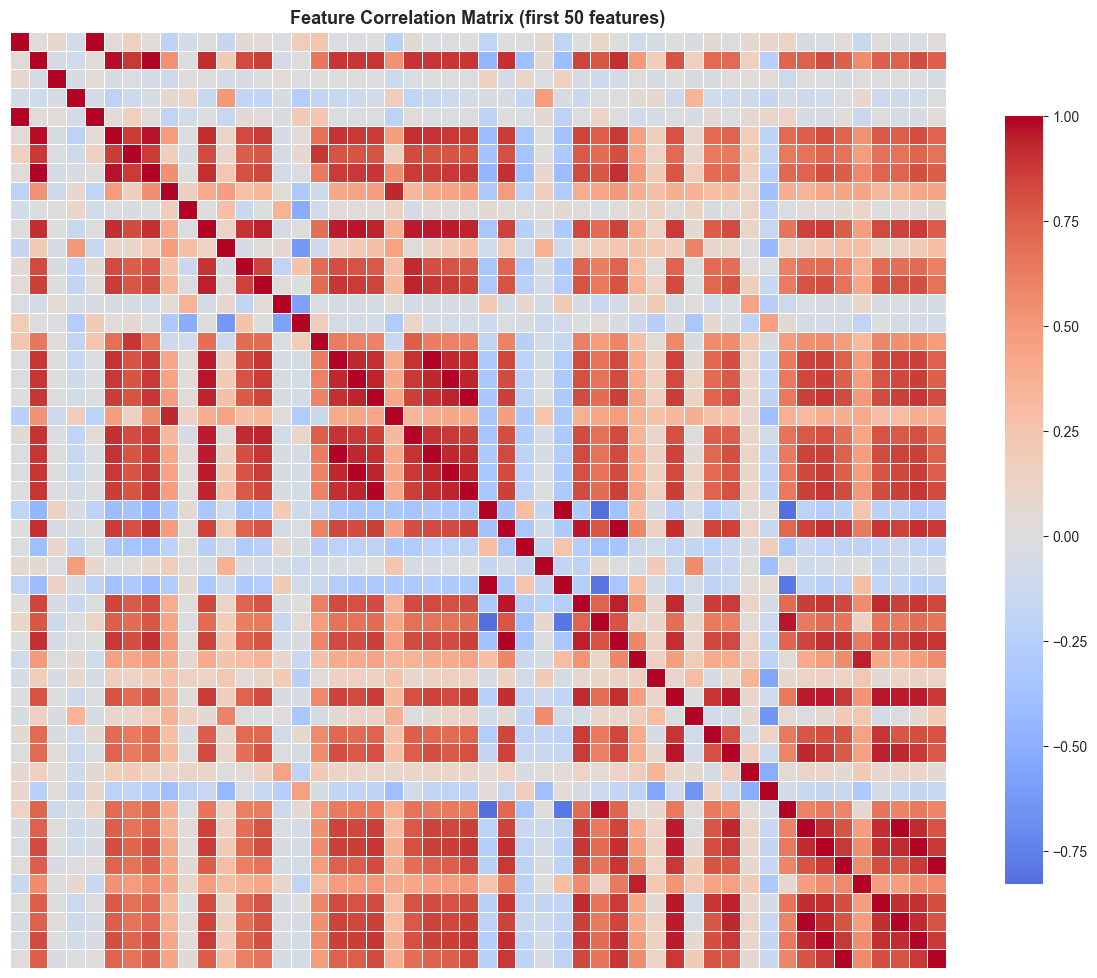


⚠️  Highly correlated pairs (|r| > 0.9): 72

Top 10 correlations:
  ch0_wavelet_energy_3           <-> ch0_wavelet_var_3             :  1.000
  ch1_wavelet_energy_3           <-> ch1_wavelet_var_3             :  1.000
  ch1_wavelet_energy_2           <-> ch1_wavelet_var_2             :  1.000
  ch1_wavelet_energy_1           <-> ch1_wavelet_var_1             :  1.000
  ch0_wavelet_energy_2           <-> ch0_wavelet_var_2             :  1.000
  ch0_wavelet_energy_1           <-> ch0_wavelet_var_1             :  1.000
  ch0_mean                       <-> ch0_median                    :  0.996
  ch0_std                        <-> ch0_peak_to_peak              :  0.996
  ch1_std                        <-> ch1_peak_to_peak              :  0.995
  ch1_mean                       <-> ch1_median                    :  0.993


In [11]:
# Compute correlation matrix (replace inf with NaN before corr to avoid propagation)
n_features_viz = min(50, X_train_features.shape[1])
features_sample = (
    X_train_features
    .replace([np.inf, -np.inf], np.nan)
    .iloc[:, :n_features_viz]
)
corr_matrix = features_sample.corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, 
           square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
           xticklabels=False, yticklabels=False)
ax.set_title(f'Feature Correlation Matrix (first {n_features_viz} features)', 
            fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Find highly correlated pairs
high_corr_threshold = 0.9
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if np.isfinite(val) and abs(val) > high_corr_threshold:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                val
            ))

print(f"\n⚠️  Highly correlated pairs (|r| > {high_corr_threshold}): {len(high_corr_pairs)}")
if len(high_corr_pairs) > 0:
    print("\nTop 10 correlations:")
    for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:10]:
        print(f"  {feat1:30s} <-> {feat2:30s}: {corr:6.3f}")

## 9. Class Separability Analysis

Measure how well features separate Freeze from No Freeze using effect size (Cohen's d).

📊 Top 15 Features by Effect Size (Cohen's d):
   Higher effect size = better class separability
   d > 0.8: Large effect
   d > 0.5: Medium effect
   d > 0.2: Small effect
 1. gyr_lower_back_mag_peak_to_peak     d=1.253  (Large)
 2. ch3_peak_to_peak                    d=1.242  (Large)
 3. ch0_kurt                            d=1.212  (Large)
 4. gyr_lower_back_mag_mean             d=1.191  (Large)
 5. gyr_lower_back_mag_rms              d=1.179  (Large)
 6. gyr_lower_back_mag_median           d=1.174  (Large)
 7. ch5_peak_to_peak                    d=1.174  (Large)
 8. ch3_std                             d=1.162  (Large)
 9. ch3_rms                             d=1.161  (Large)
10. gyr_lower_back_mag_std              d=1.147  (Large)
11. ch5_rms                             d=1.072  (Large)
12. ch4_peak_to_peak                    d=1.069  (Large)
13. ch3_iqr                             d=1.053  (Large)
14. ch4_rms                             d=1.044  (Large)
15. gyr_lower_back_mag_freezin

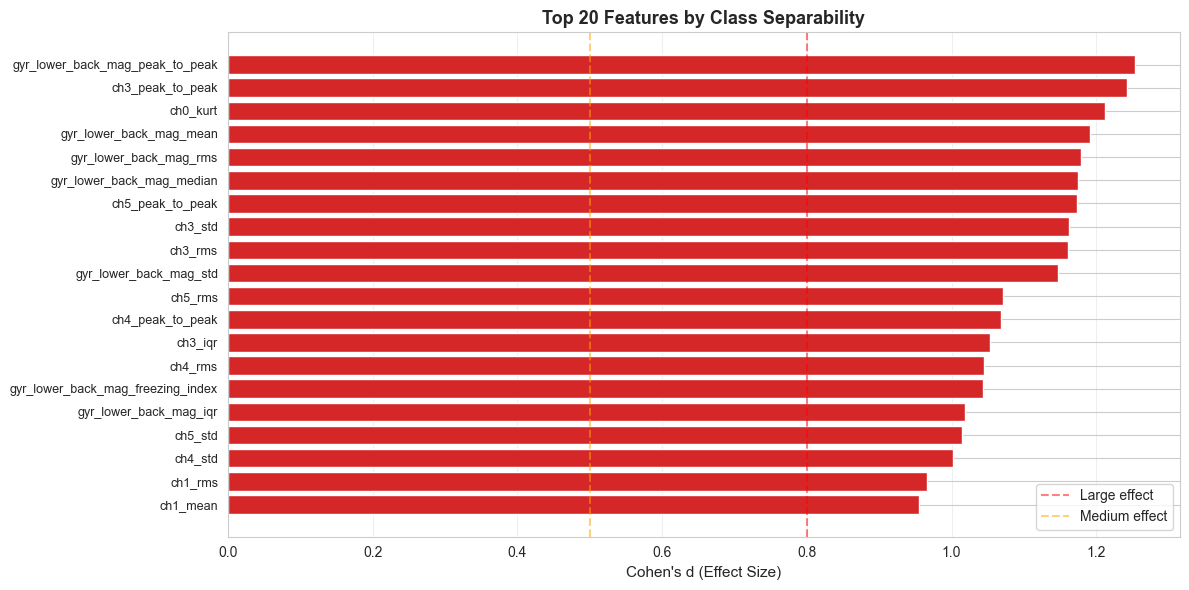

In [12]:
# Calculate Cohen's d for each feature
def cohens_d(group1, group2):
    """Calculate Cohen's d effect size."""
    mean1, mean2 = group1.mean(), group2.mean()
    std1, std2 = group1.std(), group2.std()
    n1, n2 = len(group1), len(group2)
    pooled_std = np.sqrt(((n1-1)*std1**2 + (n2-1)*std2**2) / (n1+n2-2))
    return abs((mean1 - mean2) / pooled_std) if pooled_std > 0 else 0

effect_sizes = {}
for col in X_train_features.columns:
    d = cohens_d(features_no_freeze[col].dropna(), features_freeze[col].dropna())
    effect_sizes[col] = d

effect_sizes = pd.Series(effect_sizes).sort_values(ascending=False)

print("📊 Top 15 Features by Effect Size (Cohen's d):")
print("=" * 70)
print("   Higher effect size = better class separability")
print("   d > 0.8: Large effect")
print("   d > 0.5: Medium effect")
print("   d > 0.2: Small effect")
print("=" * 70)
for i, (feat, d) in enumerate(effect_sizes.head(15).items(), 1):
    magnitude = "Large" if d > 0.8 else "Medium" if d > 0.5 else "Small" if d > 0.2 else "Negligible"
    print(f"{i:2d}. {feat:35s} d={d:5.3f}  ({magnitude})")

# Visualize top features by effect size
fig, ax = plt.subplots(figsize=(12, 6))
top_effects = effect_sizes.head(20)
colors = ['#d62728' if d > 0.8 else '#ff7f0e' if d > 0.5 else '#2ca02c' for d in top_effects.values]
ax.barh(range(len(top_effects)), top_effects.values, color=colors)
ax.set_yticks(range(len(top_effects)))
ax.set_yticklabels(top_effects.index, fontsize=9)
ax.set_xlabel("Cohen's d (Effect Size)", fontsize=11)
ax.set_title('Top 20 Features by Class Separability', fontsize=13, fontweight='bold')
ax.axvline(x=0.8, color='red', linestyle='--', alpha=0.5, label='Large effect')
ax.axvline(x=0.5, color='orange', linestyle='--', alpha=0.5, label='Medium effect')
ax.legend()
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 10. Summary

In [13]:
# Summary statistics
total_train = sum([len(fold['y_train']) for fold in loso_splits])
total_test = sum([len(fold['y_test']) for fold in loso_splits])

print("=" * 70)
print("FEATURE EXTRACTION SUMMARY")
print("=" * 70)

print(f"\n📊 Feature Configuration:")
print(f"   Time-domain: ✅ Enabled")
print(f"   Frequency-domain: ✅ Enabled")
print(f"   Wavelet: ✅ Enabled")
print(f"   Nonlinear: ❌ Disabled")

print(f"\n📈 Processing Statistics:")
print(f"   LOSO folds: {len(loso_splits)}")
print(f"   Total train windows: {total_train:,}")
print(f"   Total test windows: {total_test:,}")
print(f"   Features per window: {X_train_features.shape[1]}")

print(f"\n🧹 Signal Cleaning:")
print(f"   Method: MAD-based outlier detection")
print(f"   Interpolation: Polynomial (order 3)")
print(f"   Threshold: 3.0 × MAD")

print(f"\n💾 Output:")
print(f"   Directory: {feature_output_dir}")
print(f"   Files per fold: X_train_features.csv, y_train.csv, X_test_features.csv, y_test.csv")

print(f"\n🎯 Key Insights:")
print(f"   Top feature (variance): {feature_variance.index[0]}")
print(f"   Top feature (effect size): {effect_sizes.index[0]} (d={effect_sizes.iloc[0]:.3f})")
print(f"   Highly correlated pairs: {len(high_corr_pairs)}")

print("\n" + "=" * 70)
print("✅ Dataset ready for training!")
print("📌 Next step: Run notebook 04_loso_pipeline_and_training.ipynb")
print("=" * 70)

FEATURE EXTRACTION SUMMARY

📊 Feature Configuration:
   Time-domain: ✅ Enabled
   Frequency-domain: ✅ Enabled
   Wavelet: ✅ Enabled
   Nonlinear: ❌ Disabled

📈 Processing Statistics:
   LOSO folds: 24
   Total train windows: 97,763
   Total test windows: 1,410
   Features per window: 201

🧹 Signal Cleaning:
   Method: MAD-based outlier detection
   Interpolation: Polynomial (order 3)
   Threshold: 3.0 × MAD

💾 Output:
   Directory: ..\..\outputs\figshare_features
   Files per fold: X_train_features.csv, y_train.csv, X_test_features.csv, y_test.csv

🎯 Key Insights:
   Top feature (variance): gyr_lower_back_mag_wavelet_energy_0
   Top feature (effect size): gyr_lower_back_mag_peak_to_peak (d=1.253)
   Highly correlated pairs: 72

✅ Dataset ready for training!
📌 Next step: Run notebook 04_loso_pipeline_and_training.ipynb
